<a href="https://colab.research.google.com/github/MW-12/Email-Campaign-Analysis-SQL-Advanced/blob/main/Python_for_DA_Module_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount("/content/drive")

%cd /content/drive/MyDrive/Mate_homework/

events=pd.read_csv("events.csv")
products=pd.read_csv("products.csv")
countries=pd.read_csv("countries.csv")





Mounted at /content/drive
/content/drive/MyDrive/Mate_homework


In [ ]:
events['Order Date']=pd.to_datetime(events['Order Date'])
events['Ship Date']=pd.to_datetime(events['Ship Date'])

In [ ]:
print("Events:")
print(events.head())
print("\nProducts:")
print(products.head())
print("\nCountries:")
print(countries.head())

Events:
    Order ID Order Date  Ship Date Order Priority Country Code  Product ID  \
0  100640618 2014-10-08 2014-10-18              M          NOR        2103   
1  100983083 2016-08-11 2016-08-11              C          SRB        2103   
2  101025998 2014-07-18 2014-08-11              M          NaN        7940   
3  102230632 2017-05-13 2017-06-13              L          MNE        2455   
4  103435266 2012-08-11 2012-09-18              H          SRB        1270   

  Sales Channel  Units Sold  Unit Price  Unit Cost  
0        Online       650.0      205.70     117.11  
1       Offline      1993.0      205.70     117.11  
2        Online      4693.0      668.27     502.54  
3        Online      1171.0      109.28      35.84  
4       Offline      7648.0       47.45      31.79  

Products:
     id        item_type
0  2103           Cereal
1  7940        Household
2  2455          Clothes
3  1270        Beverages
4  8681  Office Supplies

Countries:
             name alpha-2 alpha-

In [ ]:
print("Events:")
print(events.info())
print("\nProducts:")
print(products.info())
print("\nCountries:")
print(countries.info())

Events:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1330 non-null   int64         
 1   Order Date      1330 non-null   datetime64[ns]
 2   Ship Date       1330 non-null   datetime64[ns]
 3   Order Priority  1330 non-null   object        
 4   Country Code    1248 non-null   object        
 5   Product ID      1330 non-null   int64         
 6   Sales Channel   1330 non-null   object        
 7   Units Sold      1328 non-null   float64       
 8   Unit Price      1330 non-null   float64       
 9   Unit Cost       1330 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 104.0+ KB
None

Products:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     -----

In [ ]:
print("Events:")
print(events.describe())
print("\nProducts:")
print(products.describe())
print("\nCountries:")
print(countries.describe())

Events:
           Order ID                     Order Date  \
count  1.330000e+03                           1330   
mean   5.412048e+08  2013-10-12 06:09:12.180451072   
min    1.006406e+08            2010-01-01 00:00:00   
25%    3.190004e+08            2011-12-16 06:00:00   
50%    5.387164e+08            2013-10-17 00:00:00   
75%    7.544628e+08            2015-08-28 18:00:00   
max    9.998797e+08            2017-07-23 00:00:00   
std    2.573882e+08                            NaN   

                           Ship Date   Product ID   Units Sold   Unit Price  \
count                           1330  1330.000000  1328.000000  1330.000000   
mean   2013-11-06 00:46:33.383458816  5788.096241  4952.201807   264.893541   
min              2010-01-10 00:00:00  1270.000000     2.000000     9.330000   
25%              2012-01-03 00:00:00  3127.000000  2356.750000    81.730000   
50%              2013-11-09 00:00:00  5988.000000  4962.000000   154.060000   
75%              2015-10-03 18:

<a name="conclusions"></a>
# Conclusions
## General Conclusions
Here we have three DataFrames: "Events," "Products," and "Countries."

## DataFrame "Events"
The "Events" DataFrame contains 10 columns and 1330 entries, though not all columns are fully populated, which suggests missing data. The columns "Order Date" and "Ship Date" had an incorrect data type and required conversion to the datetime64[ns] format.

The `.describe()` output shows that "Order Date" ranges from 2010-01-01 to 2017-07-23, while "Ship Date" ranges from 2010-01-10 to 2017-08-31, covering roughly 7.5 years of transactions. "Units Sold" has only 1328 non-null values (2 missing), ranging from 2 to 9999 units, with a mean of 4952 and a median of 4962 — a fairly symmetric distribution. "Unit Price" ranges from 9.33 to 668.27, with a mean of 264.89, while "Unit Cost" ranges from 6.92 to 524.96, with a mean of 187.25.

After verifying the missing data, no key columns were affected. Since the 82 missing-value records represented at most 6.17% of the data (the peak value, with all other columns below 1%), these rows were removed via `.dropna()`.

## DataFrame "Products"
The "Products" DataFrame contains only 12 entries in 2 columns, containing only information about item ID and name.

## DataFrame "Countries"
The "Countries" DataFrame contains information about countries, such as full name, codes, and region. It has 5 columns and 249 entries. Initial analysis showed 1 missing value in both "alpha-2" and "sub-region."

Further investigation revealed that these were not true missing values: Namibia's alpha-2 code ("NA") was misinterpreted as NaN during data loading, since pandas treats the string "NA" as a null value by default. This was corrected by manually reassigning the value. Antarctica's missing "region" and "sub-region" values are legitimate, as it is not classified as a sovereign country under the UN geoscheme, and were therefore left unchanged.

In [ ]:
print(events.isna().sum() / len(events) * 100)
print(products.isna().sum() / len(products) * 100)
print(countries.isna().sum() / len(countries) * 100)

Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      6.165414
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.150376
Unit Price        0.000000
Unit Cost         0.000000
dtype: float64
id           0.0
item_type    0.0
dtype: float64
name          0.000000
alpha-2       0.401606
alpha-3       0.000000
region        0.401606
sub-region    0.401606
dtype: float64


In [ ]:
events['Country Code'].isna().sum()


np.int64(82)

In [ ]:
events[events['Country Code'].isna()].head(20)


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
2,101025998,2014-07-18,2014-08-11,M,NaN,7940,Online,4693.0,668.27,502.54
13,104548490,2014-01-01,2014-01-05,M,NaN,7331,Online,7076.0,255.28,159.42
26,117929494,2015-01-24,2015-03-02,H,NaN,4594,Offline,6813.0,9.33,6.92
29,118859469,2011-06-02,2011-07-01,L,NaN,8969,Offline,2013.0,152.58,97.44
43,126948583,2017-05-24,2017-07-09,C,NaN,7331,Online,5762.0,255.28,159.42
48,128766906,2011-02-13,2011-03-28,C,NaN,7940,Offline,3844.0,668.27,502.54
50,129169023,2012-06-08,2012-07-18,M,NaN,1270,Offline,2839.0,47.45,31.79
58,133276450,2016-01-27,2016-03-15,H,NaN,3127,Online,8318.0,81.73,56.67
66,139949357,2014-07-01,2014-07-14,H,NaN,5988,Online,2980.0,154.06,90.93
83,150293242,2015-05-19,2015-06-21,H,NaN,8681,Offline,3965.0,651.21,524.96


In [ ]:
countries[countries['alpha-2'].isna()].head()

,name,alpha-2,alpha-3,region,sub-region
153,Namibia,NaN,NAM,Africa,Sub-Saharan Africa


In [ ]:
countries[countries['sub-region'].isna()].head()

,name,alpha-2,alpha-3,region,sub-region
8,Antarctica,AQ,ATA,NaN,NaN


In [ ]:

events[events['Country Code'].isna()]['Sales Channel'].value_counts()




,count
Sales Channel,
Offline,44
Online,38


After verifying the missing data, I didn't find any key in those columns. The 82 records with missing data (6.17% of all data) represent the peak value — the rest of the columns had less than 1% missing data. Because this percentage is relatively low, I decided to delete those rows.

In [ ]:
events_clean = events.dropna()
products_clean = products.dropna()
countries.loc[countries['name'] == 'Namibia', 'alpha-2'] = 'NA'
countries_clean = countries.copy()

In [ ]:
print(events_clean.isna().sum() / len(events) * 100)
print(products_clean.isna().sum() / len(products) * 100)
print(countries_clean.isna().sum() / len(countries) * 100)

Order ID          0.0
Order Date        0.0
Ship Date         0.0
Order Priority    0.0
Country Code      0.0
Product ID        0.0
Sales Channel     0.0
Units Sold        0.0
Unit Price        0.0
Unit Cost         0.0
dtype: float64
id           0.0
item_type    0.0
dtype: float64
name          0.000000
alpha-2       0.000000
alpha-3       0.000000
region        0.401606
sub-region    0.401606
dtype: float64


In [ ]:
print(events_clean.duplicated().sum())
print(products_clean.duplicated().sum())
print(countries_clean.duplicated().sum())

0
0
0


In [ ]:
events_clean['Order ID'].duplicated().sum()

np.int64(0)

In [ ]:
print(products_clean['id'].duplicated().sum())
print(countries_clean['alpha-2'].duplicated().sum())
print(countries_clean['alpha-3'].duplicated().sum())
print(countries_clean['name'].duplicated().sum())

0
0
0
0


looking for any anomalies


<Axes: >

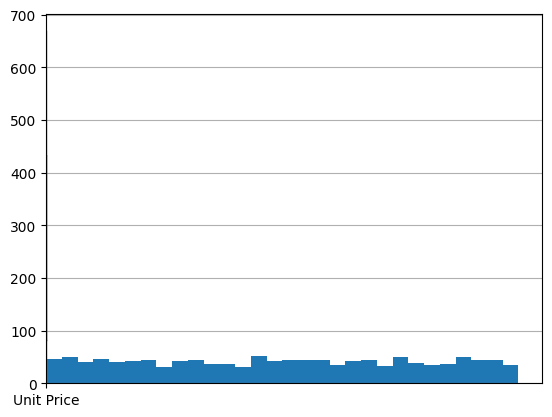

In [ ]:
events_clean['Units Sold'].hist(bins=30)
events_clean.boxplot(column='Unit Price')

In [ ]:
Q1 = events_clean['Unit Price'].quantile(0.25)
Q3 = events_clean['Unit Price'].quantile(0.75)
IQR = Q3 - Q1
outliers = events_clean[(events_clean['Unit Price'] < Q1 - 1.5*IQR) |
                          (events_clean['Unit Price'] > Q3 + 1.5*IQR)]
print(outliers)

Empty DataFrame
Columns: [Order ID, Order Date, Ship Date, Order Priority, Country Code, Product ID, Sales Channel, Units Sold, Unit Price, Unit Cost]
Index: []


In [ ]:
(events_clean['Ship Date'] < events_clean['Order Date']).sum()

np.int64(0)

In [ ]:
(events_clean['Unit Cost'] > events_clean['Unit Price']).sum()

np.int64(0)

In [ ]:
events_clean[~events_clean['Product ID'].isin(products_clean['id'])]

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost


In [ ]:
(events_clean['Units Sold'] <= 0).sum()
(events_clean['Unit Price'] <= 0).sum()

np.int64(0)

Joining data.

In [ ]:
combain_data = pd.merge(events_clean, products_clean, left_on='Product ID', right_on='id', how='left')
combain_data = pd.merge(combain_data, countries_clean, left_on='Country Code', right_on='alpha-3', how='left')
combain_data.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,id,item_type,name,alpha-2,alpha-3,region,sub-region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,2103,Cereal,Norway,NO,NOR,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,2103,Cereal,Serbia,RS,SRB,Europe,Southern Europe
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,2455,Clothes,Montenegro,ME,MNE,Europe,Southern Europe
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,1270,Beverages,Serbia,RS,SRB,Europe,Southern Europe
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,2220.0,651.21,524.96,8681,Office Supplies,Slovakia,SK,SVK,Europe,Eastern Europe


In [ ]:
combain_data.columns = combain_data.columns.str.lower().str.replace(' ', '_')
combain_data.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,id,item_type,name,alpha-2,alpha-3,region,sub-region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,2103,Cereal,Norway,NO,NOR,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,2103,Cereal,Serbia,RS,SRB,Europe,Southern Europe
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,2455,Clothes,Montenegro,ME,MNE,Europe,Southern Europe
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,1270,Beverages,Serbia,RS,SRB,Europe,Southern Europe
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,2220.0,651.21,524.96,8681,Office Supplies,Slovakia,SK,SVK,Europe,Eastern Europe


In [ ]:

combain_data['profit'] = (combain_data['unit_price'] - combain_data['unit_cost']) * combain_data['units_sold']
combain_data['revenue'] = combain_data['unit_price'] * combain_data['units_sold']
combain_data['cost'] = combain_data['unit_cost'] * combain_data['units_sold']
combain_data.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,id,item_type,name,alpha-2,alpha-3,region,sub-region,profit,revenue,cost
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,2103,Cereal,Norway,NO,NOR,Europe,Northern Europe,57583.50,133705.00,76121.50
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,2103,Cereal,Serbia,RS,SRB,Europe,Southern Europe,176559.87,409960.10,233400.23
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,2455,Clothes,Montenegro,ME,MNE,Europe,Southern Europe,85998.24,127966.88,41968.64
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,1270,Beverages,Serbia,RS,SRB,Europe,Southern Europe,119767.68,362897.60,243129.92
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,2220.0,651.21,524.96,8681,Office Supplies,Slovakia,SK,SVK,Europe,Eastern Europe,280275.00,1445686.20,1165411.20


In [ ]:
print(len(events_clean))

print(len(combain_data))

print(combain_data.isna().sum())

1246
1246
order_id          0
order_date        0
ship_date         0
order_priority    0
country_code      0
product_id        0
sales_channel     0
units_sold        0
unit_price        0
unit_cost         0
id                0
item_type         0
name              0
alpha-2           0
alpha-3           0
region            0
sub-region        0
profit            0
revenue           0
cost              0
dtype: int64


In [ ]:
print(combain_data['sales_channel'].value_counts())

sales_channel
Online     622
Offline    621
online       3
Name: count, dtype: int64


In [ ]:
combain_data['sales_channel'] = combain_data['sales_channel'].str.capitalize()

In [ ]:
print(combain_data['sales_channel'].value_counts())

sales_channel
Online     625
Offline    621
Name: count, dtype: int64


In [ ]:
combain_data['delivery_time'] = combain_data['ship_date'] - combain_data['order_date']

In [ ]:
combain_data['delivery_time'] = combain_data['delivery_time'].dt.days

In [ ]:
combain_data.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,...,item_type,name,alpha-2,alpha-3,region,sub-region,profit,revenue,cost,delivery_time
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,...,Cereal,Norway,NO,NOR,Europe,Northern Europe,57583.50,133705.00,76121.50,10
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,...,Cereal,Serbia,RS,SRB,Europe,Southern Europe,176559.87,409960.10,233400.23,0
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,...,Clothes,Montenegro,ME,MNE,Europe,Southern Europe,85998.24,127966.88,41968.64,31
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,...,Beverages,Serbia,RS,SRB,Europe,Southern Europe,119767.68,362897.60,243129.92,38
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,2220.0,651.21,524.96,...,Office Supplies,Slovakia,SK,SVK,Europe,Eastern Europe,280275.00,1445686.20,1165411.20,34


In [ ]:
combain_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1246 entries, 0 to 1245
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1246 non-null   int64         
 1   order_date      1246 non-null   datetime64[ns]
 2   ship_date       1246 non-null   datetime64[ns]
 3   order_priority  1246 non-null   object        
 4   country_code    1246 non-null   object        
 5   product_id      1246 non-null   int64         
 6   sales_channel   1246 non-null   object        
 7   units_sold      1246 non-null   float64       
 8   unit_price      1246 non-null   float64       
 9   unit_cost       1246 non-null   float64       
 10  id              1246 non-null   int64         
 11  item_type       1246 non-null   object        
 12  name            1246 non-null   object        
 13  alpha-2         1246 non-null   object        
 14  alpha-3         1246 non-null   object        
 15  regi

## Key Performance Indicators


In [ ]:
total_orders = combain_data['order_id'].nunique()
total_revenue = combain_data['revenue'].sum()
total_cost = combain_data['cost'].sum()
total_profit = combain_data['profit'].sum()
total_countries = combain_data['name'].nunique()
unique_countries = combain_data['name'].unique()


print(f"Total Orders: {total_orders}")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Cost: ${total_cost:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Countries: {total_countries}")
print(unique_countries)

Total Orders: 1246
Total Revenue: $1,598,983,761.26
Total Cost: $1,125,274,726.20
Total Profit: $473,709,035.06
Total Countries: 45
['Norway' 'Serbia' 'Montenegro' 'Slovakia' 'France' 'Spain' 'Croatia'
 'Germany' 'Armenia' 'Georgia' 'United Kingdom' 'Slovenia' 'Romania'
 'Poland' 'Luxembourg' 'Cyprus' 'Belgium' 'Lithuania' 'Russia' 'Malta'
 'Ukraine' 'Czech Republic' 'Portugal' 'Belarus' 'Estonia' 'Austria'
 'Macedonia' 'San Marino' 'Netherlands' 'Switzerland' 'Hungary' 'Latvia'
 'Bulgaria' 'Italy' 'Ireland' 'Andorra' 'Liechtenstein' 'Finland'
 'Albania' 'Sweden' 'Bosnia and Herzegovina' 'Denmark' 'Monaco' 'Iceland'
 'Greece']


Data Agregation

In [ ]:
category_summary = combain_data.groupby('item_type').agg(
    total_revenue=('revenue', 'sum'),
    total_cost=('cost', 'sum'),
    total_profit=('profit', 'sum'),
    total_units_sold=('units_sold', 'sum')
).sort_values('total_profit', ascending=False)

print(category_summary)

                 total_revenue    total_cost  total_profit  total_units_sold
item_type                                                                   
Cosmetics         2.213054e+08  1.332945e+08   88010907.56          506188.0
Office Supplies   3.786662e+08  3.052543e+08   73411976.25          581481.0
Household         2.788744e+08  2.097140e+08   69160454.84          417308.0
Baby Food         1.338344e+08  8.357833e+07   50256042.90          524265.0
Clothes           6.330732e+07  2.076258e+07   42544746.72          579313.0
Cereal            9.467672e+07  5.390175e+07   40774964.94          460266.0
Vegetables        8.203849e+07  4.842113e+07   33617356.30          532510.0
Meat              2.013398e+08  1.740421e+08   27297727.60          477233.0
Snacks            6.921349e+07  4.420083e+07   25012661.94          453621.0
Personal Care     4.334632e+07  3.005550e+07   13290821.60          530360.0
Beverages         2.742567e+07  1.837433e+07    9051339.06          577991.0

In [ ]:
region_summary = combain_data.groupby('region').agg(
    total_revenue=('revenue', 'sum'),
    total_cost=('cost', 'sum'),
    total_profit=('profit', 'sum'),
    total_units_sold=('units_sold', 'sum')
).sort_values('total_profit', ascending=False)

print(region_summary)

        total_revenue    total_cost  total_profit  total_units_sold
region                                                             
Europe   1.505653e+09  1.057096e+09  4.485568e+08         5761244.0
Asia     9.333089e+07  6.817863e+07  2.515225e+07          410427.0


In [ ]:
channel_summary = combain_data.groupby('sales_channel').agg(
    total_revenue=('revenue', 'sum'),
    total_cost=('cost', 'sum'),
    total_profit=('profit', 'sum'),
    total_units_sold=('units_sold', 'sum')
).sort_values('total_profit', ascending=False)

print(channel_summary)

               total_revenue    total_cost  total_profit  total_units_sold
sales_channel                                                             
Offline         8.100305e+08  5.715191e+08  2.385113e+08         3113412.0
Online          7.889533e+08  5.537556e+08  2.351977e+08         3058259.0


In [ ]:
combain_data.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,...,item_type,name,alpha-2,alpha-3,region,sub-region,profit,revenue,cost,delivery_time
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,...,Cereal,Norway,NO,NOR,Europe,Northern Europe,57583.50,133705.00,76121.50,10
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,...,Cereal,Serbia,RS,SRB,Europe,Southern Europe,176559.87,409960.10,233400.23,0
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,...,Clothes,Montenegro,ME,MNE,Europe,Southern Europe,85998.24,127966.88,41968.64,31
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,...,Beverages,Serbia,RS,SRB,Europe,Southern Europe,119767.68,362897.60,243129.92,38
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,2220.0,651.21,524.96,...,Office Supplies,Slovakia,SK,SVK,Europe,Eastern Europe,280275.00,1445686.20,1165411.20,34


In [ ]:
combain_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1246 entries, 0 to 1245
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1246 non-null   int64         
 1   order_date      1246 non-null   datetime64[ns]
 2   ship_date       1246 non-null   datetime64[ns]
 3   order_priority  1246 non-null   object        
 4   country_code    1246 non-null   object        
 5   product_id      1246 non-null   int64         
 6   sales_channel   1246 non-null   object        
 7   units_sold      1246 non-null   float64       
 8   unit_price      1246 non-null   float64       
 9   unit_cost       1246 non-null   float64       
 10  id              1246 non-null   int64         
 11  item_type       1246 non-null   object        
 12  name            1246 non-null   object        
 13  alpha-2         1246 non-null   object        
 14  alpha-3         1246 non-null   object        
 15  regi

In [ ]:
combain_data = combain_data.drop(columns=['id', 'country_code', 'alpha-2', 'order_priority'])

# Data Visualization
## By Category

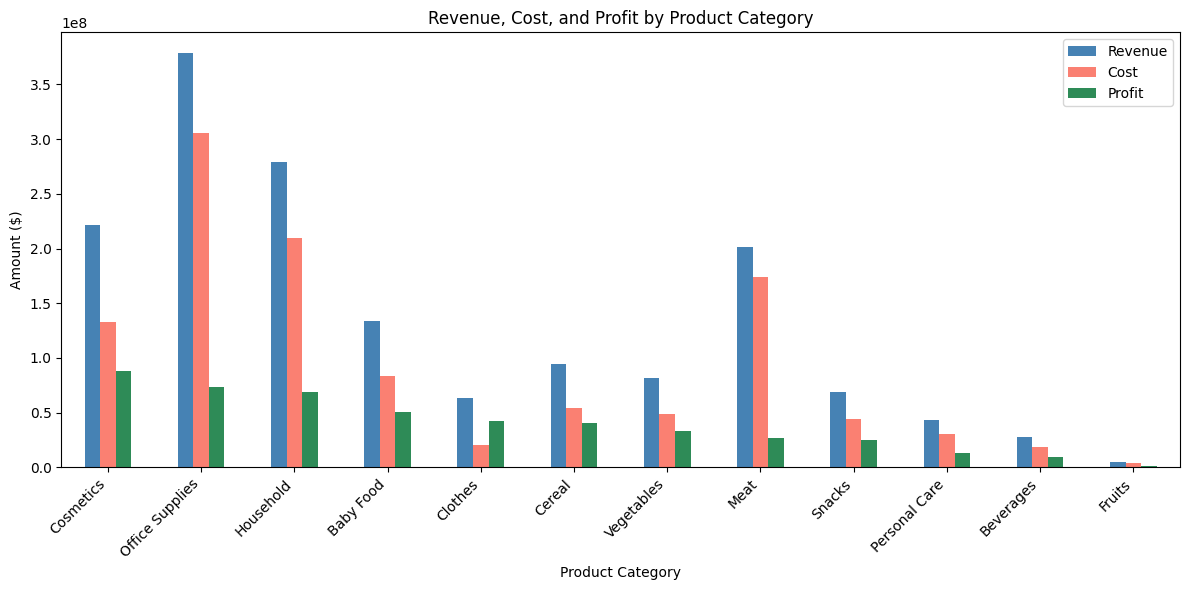

In [ ]:
category_summary[['total_revenue', 'total_cost', 'total_profit']].plot(
    kind='bar', figsize=(12, 6), color=['steelblue', 'salmon', 'seagreen']
)
plt.title('Revenue, Cost, and Profit by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Amount ($)')
plt.xticks(rotation=45, ha='right')
plt.legend(['Revenue', 'Cost', 'Profit'])
plt.tight_layout()
plt.show()


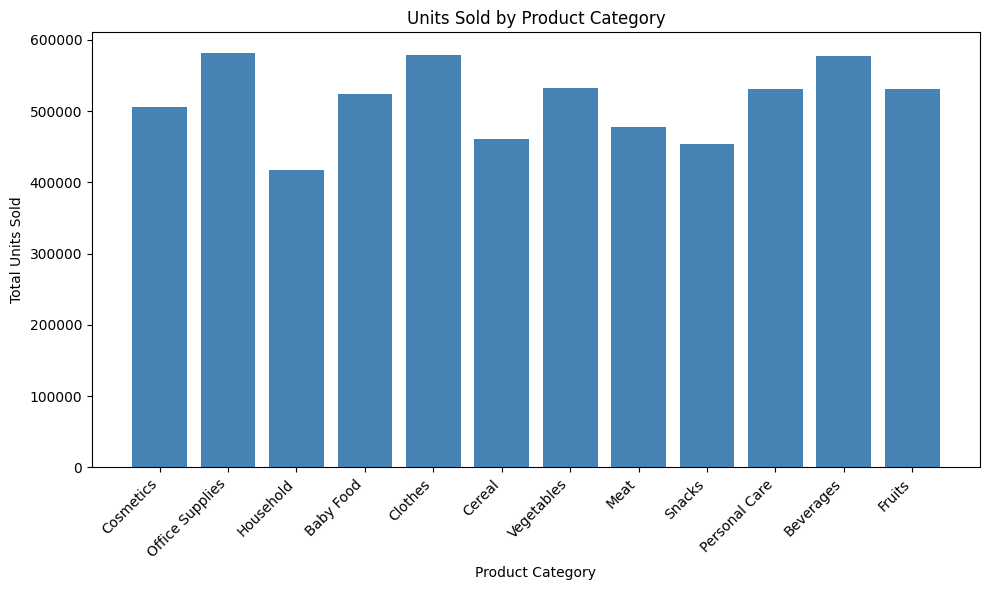

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(category_summary.index, category_summary['total_units_sold'], color='steelblue')
plt.title('Units Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## By Region

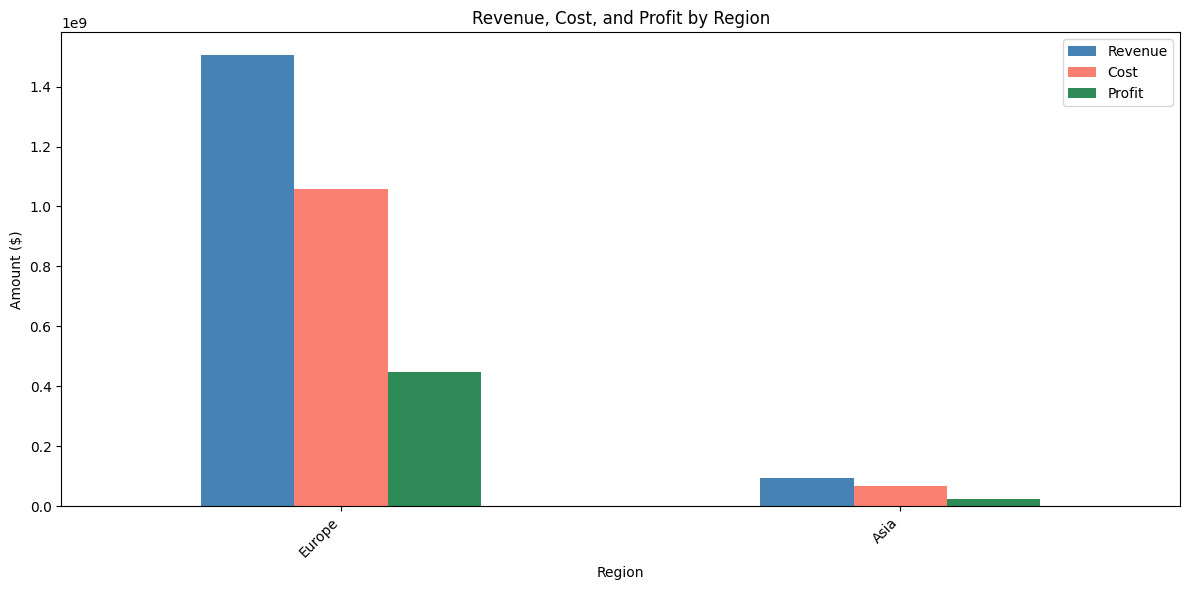

In [ ]:
region_summary[['total_revenue', 'total_cost', 'total_profit']].plot(
    kind='bar', figsize=(12, 6), color=['steelblue', 'salmon', 'seagreen']
)
plt.title('Revenue, Cost, and Profit by Region')
plt.xlabel('Region')
plt.ylabel('Amount ($)')
plt.xticks(rotation=45, ha='right')
plt.legend(['Revenue', 'Cost', 'Profit'])
plt.tight_layout()
plt.show()

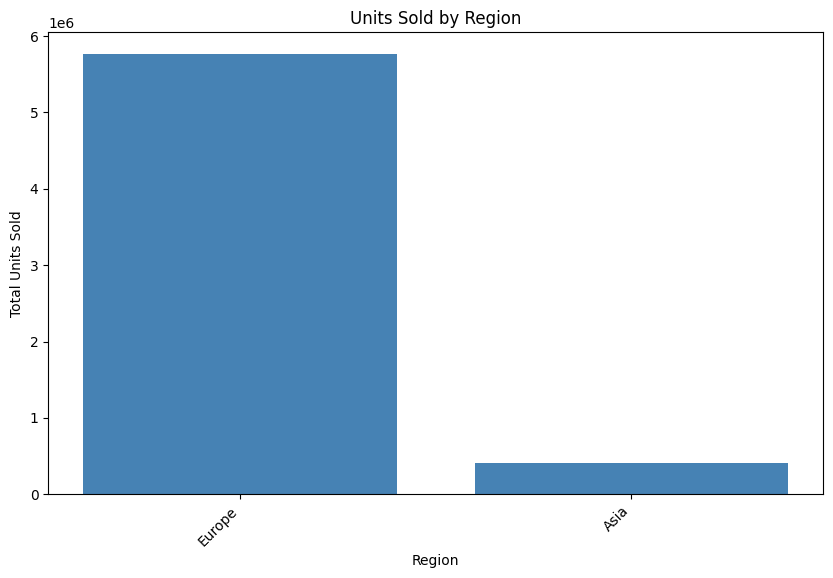

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(region_summary.index, region_summary['total_units_sold'], color='steelblue')
plt.title('Units Sold by Region')
plt.xlabel('Region')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout

plt.show()

## By Channel


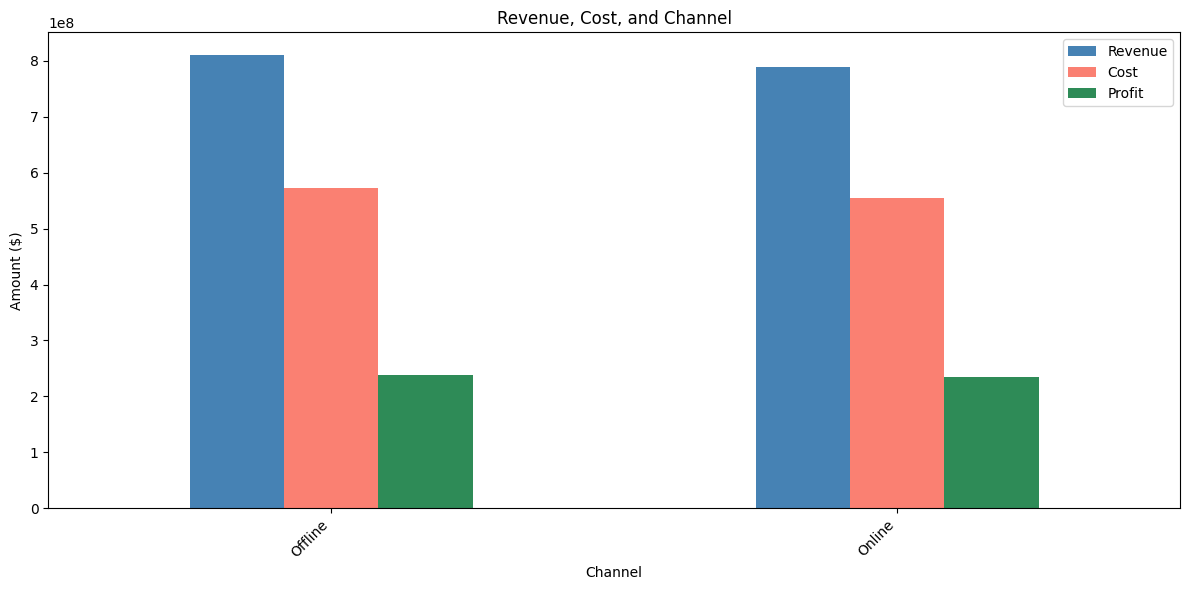

In [ ]:
channel_summary[['total_revenue', 'total_cost', 'total_profit']].plot(
    kind='bar', figsize=(12, 6), color=['steelblue', 'salmon', 'seagreen']
)
plt.title('Revenue, Cost, and Channel')
plt.xlabel('Channel')
plt.ylabel('Amount ($)')
plt.xticks(rotation=45, ha='right')
plt.legend(['Revenue', 'Cost', 'Profit'])
plt.tight_layout()
plt.show()

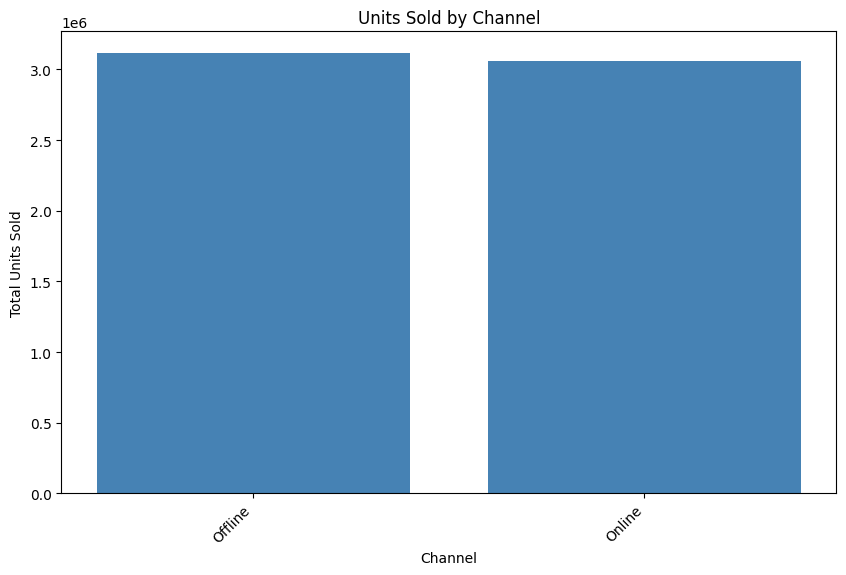

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(channel_summary.index, channel_summary['total_units_sold'], color='steelblue')
plt.title('Units Sold by Channel')
plt.xlabel('Channel')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout

plt.show()

## By Delivery Time

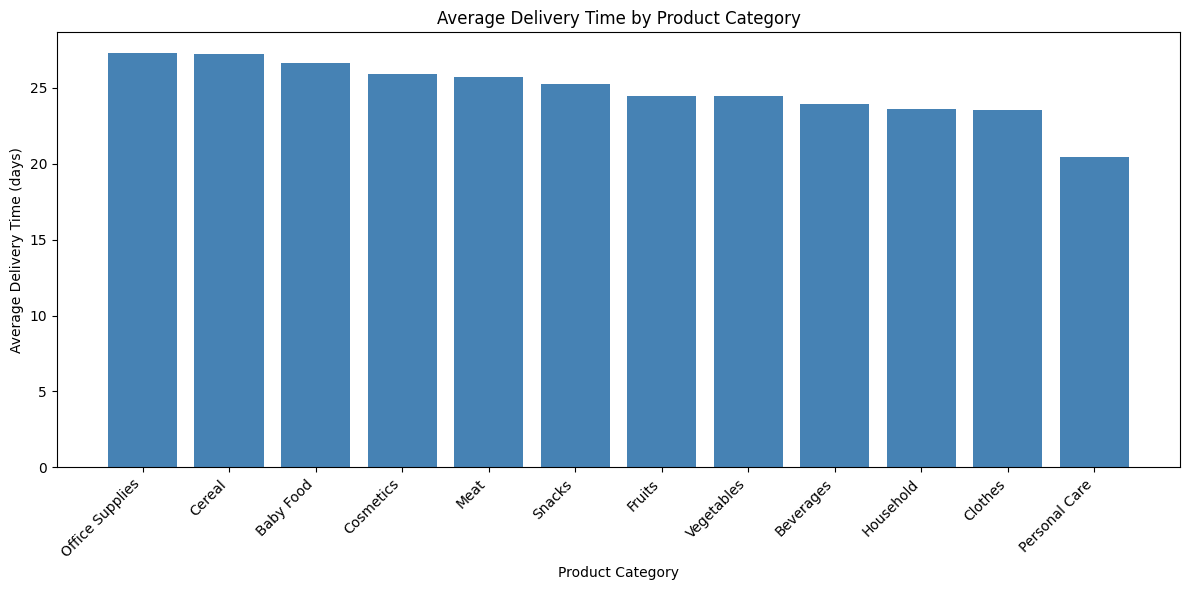

In [ ]:
category_delivery = combain_data.groupby('item_type')['delivery_time'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(category_delivery.index, category_delivery.values, color='steelblue')
plt.title('Average Delivery Time by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Delivery Time (days)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

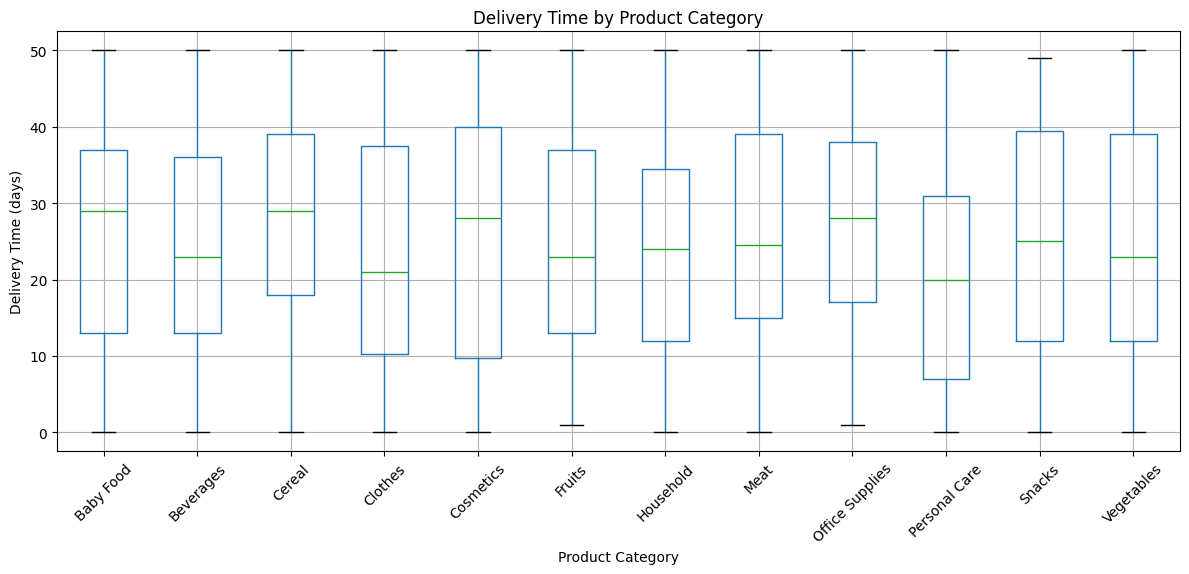

In [ ]:
combain_data.boxplot(column='delivery_time', by='item_type', figsize=(12, 6), rot=45)
plt.title('Delivery Time by Product Category')
plt.suptitle('')  # usuwa domyślny, brzydki tytuł pandas
plt.xlabel('Product Category')
plt.ylabel('Delivery Time (days)')
plt.tight_layout()
plt.show()

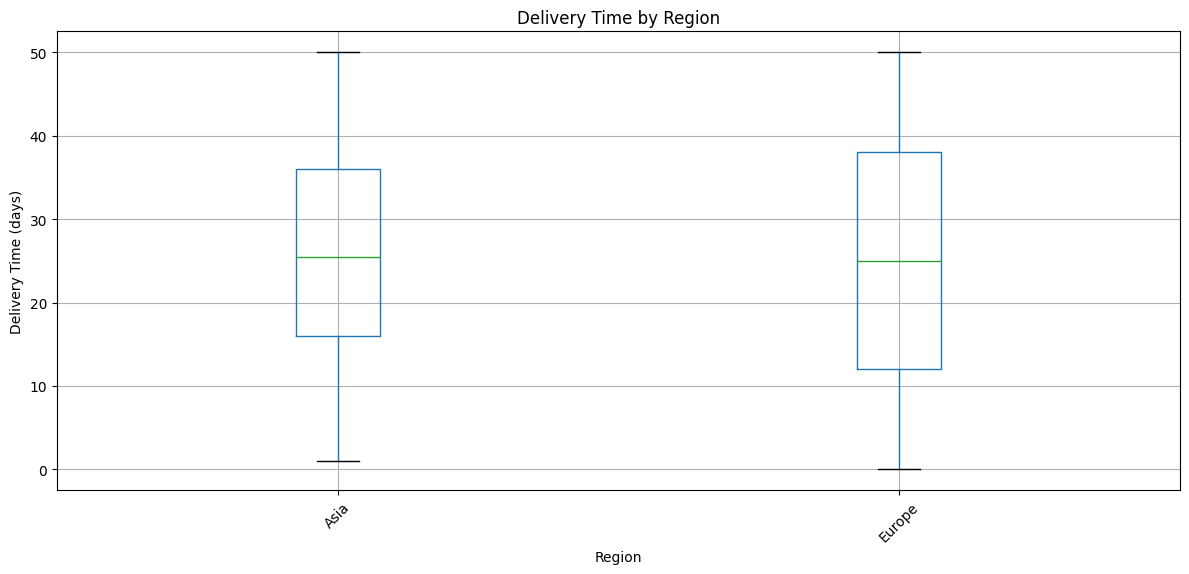

In [ ]:
combain_data.boxplot(column='delivery_time', by='region', figsize=(12, 6), rot=45)
plt.title('Delivery Time by Region')
plt.suptitle('')  # usuwa domyślny, brzydki tytuł pandas
plt.xlabel('Region')
plt.ylabel('Delivery Time (days)')
plt.tight_layout()
plt.show()

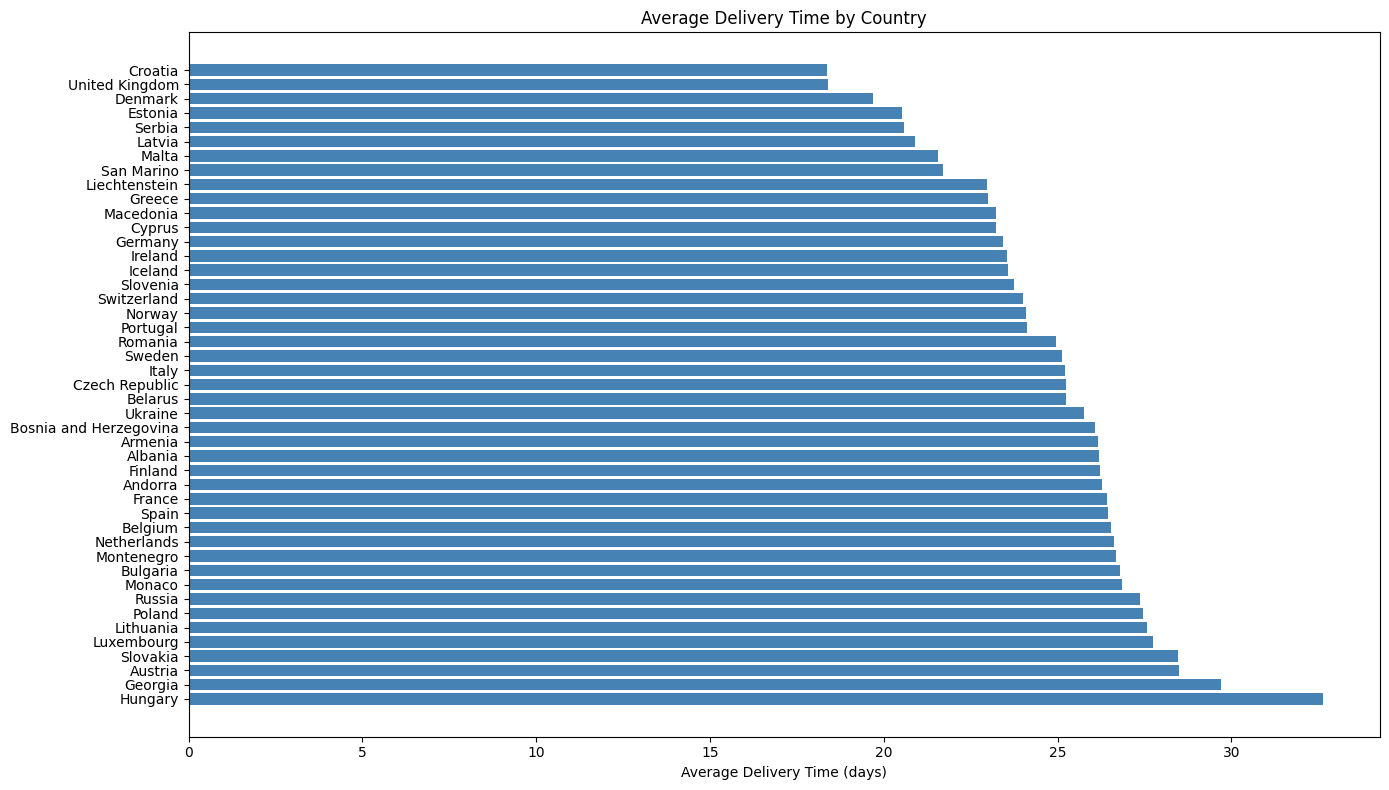

In [ ]:
country_delivery = combain_data.groupby('name')['delivery_time'].mean().sort_values(ascending=False)
plt.figure(figsize=(14,8))
plt.barh(country_delivery.index, country_delivery.values, color='steelblue')
plt.xlabel('Average Delivery Time (days)')
plt.title('Average Delivery Time by Country')
plt.tight_layout()
plt.show()

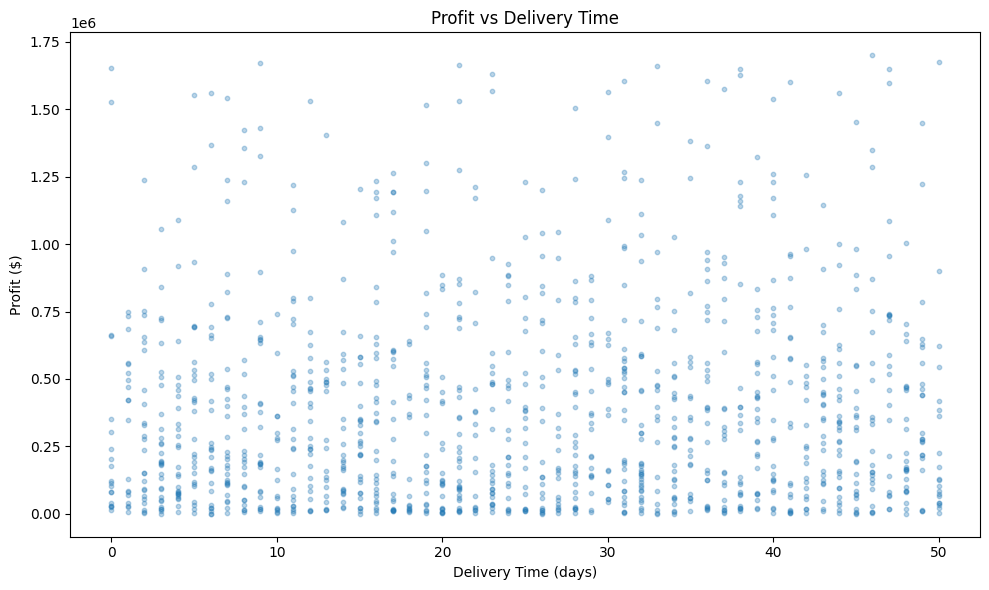

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(combain_data['delivery_time'], combain_data['profit'], alpha=0.3, s=10)
plt.xlabel('Delivery Time (days)')
plt.ylabel('Profit ($)')
plt.title('Profit vs Delivery Time')
plt.tight_layout()
plt.show()

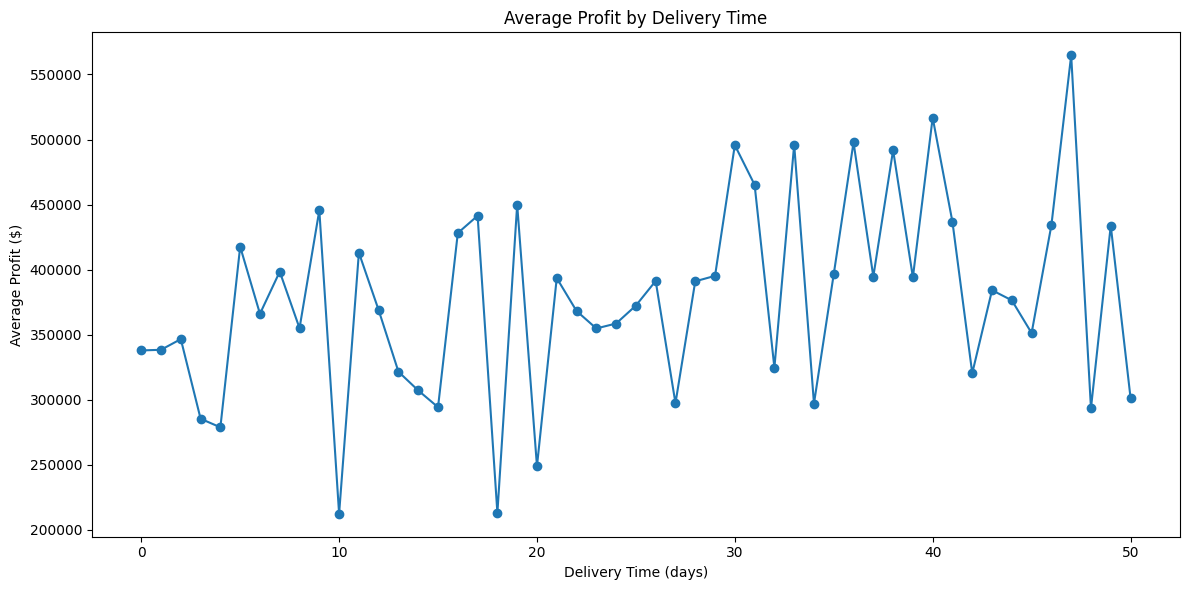

In [ ]:
profit_by_delivery = combain_data.groupby('delivery_time')['profit'].mean()
plt.figure(figsize=(12,6))
plt.plot(profit_by_delivery.index, profit_by_delivery.values, marker='o')
plt.xlabel('Delivery Time (days)')
plt.ylabel('Average Profit ($)')
plt.title('Average Profit by Delivery Time')
plt.tight_layout()
plt.show()

In [ ]:
correlation = combain_data['delivery_time'].corr(combain_data['profit'])
print(f"Correlation between delivery time and profit: {correlation:.3f}")

Correlation between delivery time and profit: 0.061


## Sales trends

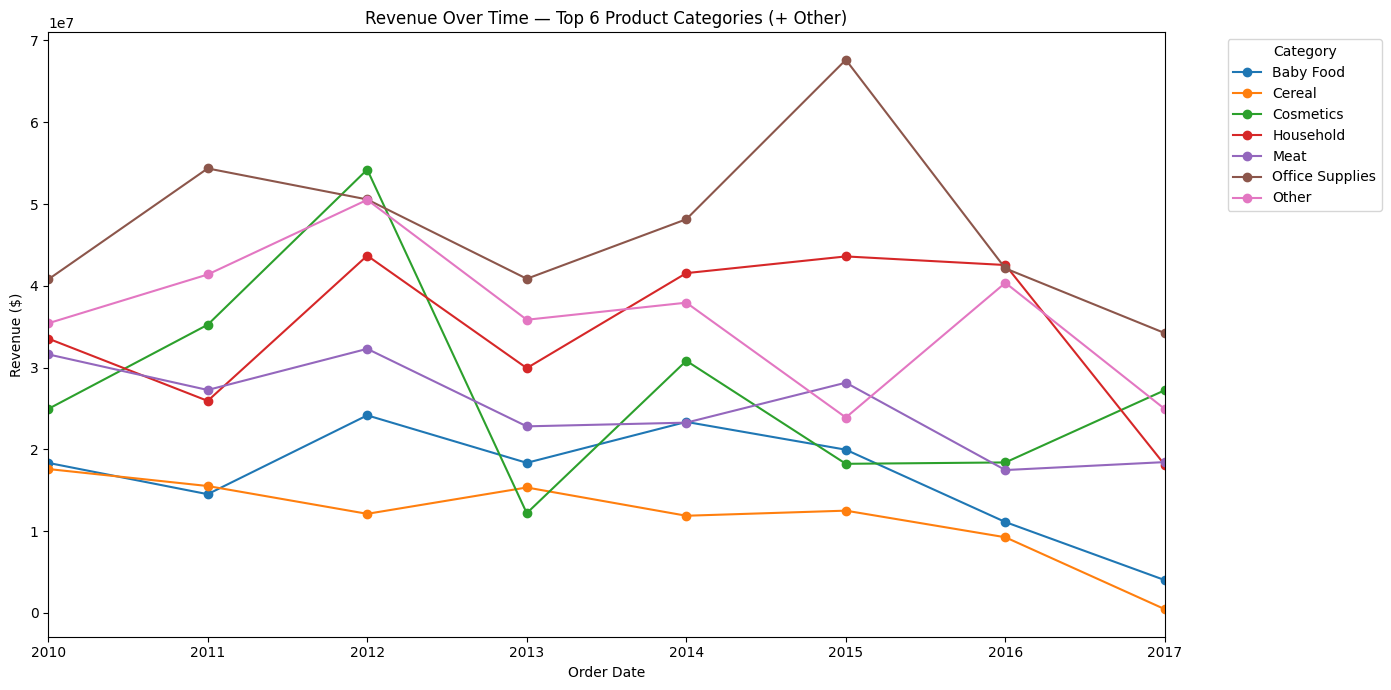

In [ ]:
top_categories = combain_data.groupby('item_type')['revenue'].sum().nlargest(6).index

combain_data['category_grouped'] = combain_data['item_type'].where(
    combain_data['item_type'].isin(top_categories), 'Other'
)

yearly_top = combain_data.groupby(
    [pd.Grouper(key='order_date', freq='YE'), 'category_grouped']
)['revenue'].sum().unstack()

yearly_top.plot(figsize=(14, 7), marker='o')
plt.title('Revenue Over Time — Top 6 Product Categories (+ Other)')
plt.xlabel('Order Date')
plt.ylabel('Revenue ($)')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
all_top_categories = combain_data.groupby('item_type')['revenue'].sum().nlargest(12).index
print(all_top_categories)


Index(['Office Supplies', 'Household', 'Cosmetics', 'Meat', 'Baby Food',
       'Cereal', 'Vegetables', 'Snacks', 'Clothes', 'Personal Care',
       'Beverages', 'Fruits'],
      dtype='object', name='item_type')


In [ ]:
combain_data.groupby('item_type')['revenue'].sum().sort_values(ascending=False)


,revenue
item_type,
Office Supplies,3.786662e+08
Household,2.788744e+08
Cosmetics,2.213054e+08
Meat,2.013398e+08
Baby Food,1.338344e+08
Cereal,9.467672e+07
Vegetables,8.203849e+07
Snacks,6.921349e+07
Clothes,6.330732e+07


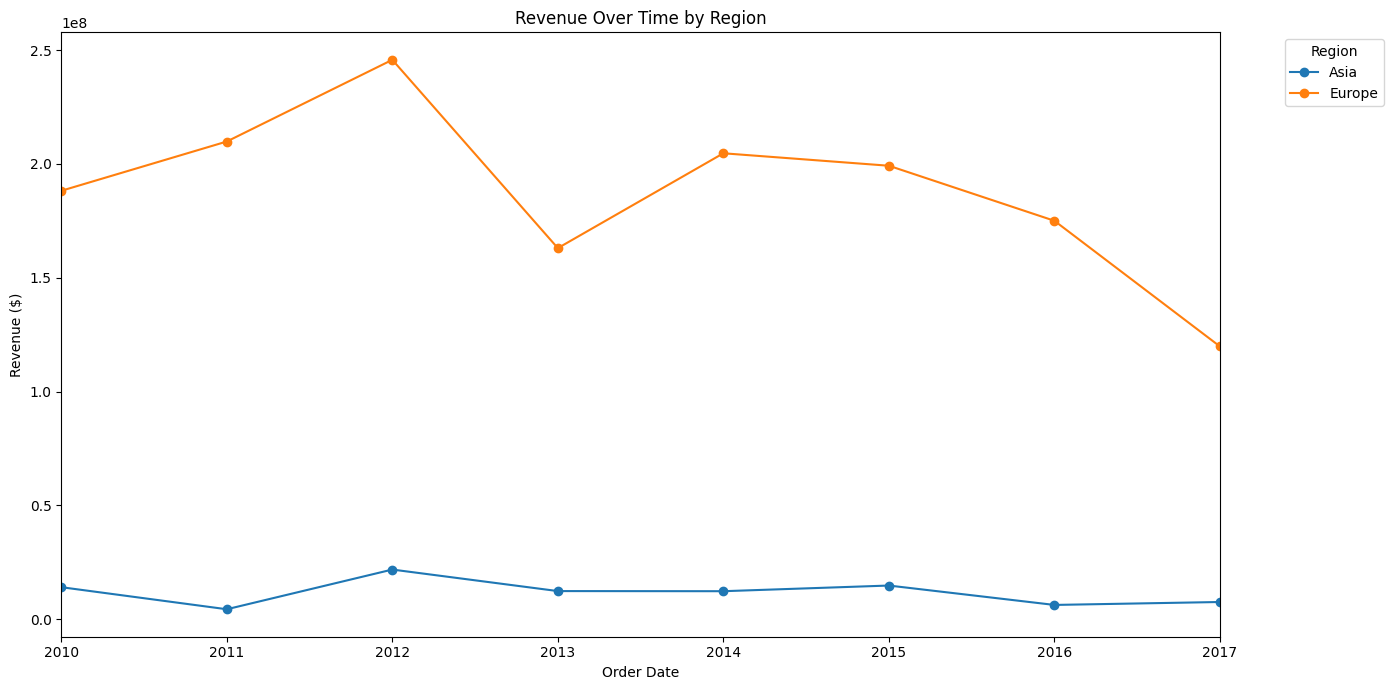

In [ ]:
yearly_by_region = combain_data.groupby(
    [pd.Grouper(key='order_date', freq='YE'), 'region']
)['revenue'].sum().unstack()

yearly_by_region.plot(figsize=(14, 7), marker='o')
plt.title('Revenue Over Time by Region')
plt.xlabel('Order Date')
plt.ylabel('Revenue ($)')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
combain_data['name'].nunique()

45

Due to the large number of countries (45), the chart below shows only the top five.

In [ ]:
top_countries = combain_data.groupby('name')['revenue'].sum().sort_values(ascending=False)
print(top_countries)

name
Czech Republic            53543932.14
Ukraine                   53252317.54
Bosnia and Herzegovina    50117508.49
Macedonia                 49222085.25
San Marino                47883708.48
Andorra                   47756693.17
Portugal                  47172189.84
Malta                     47145320.81
Russia                    46051659.81
Slovakia                  42940998.32
Hungary                   42408249.12
Serbia                    42193537.74
France                    39362112.15
Slovenia                  38892531.27
Latvia                    38722084.15
Greece                    38699541.70
Bulgaria                  38161555.70
Germany                   38055087.56
Armenia                   37519840.21
Italy                     35878352.12
Austria                   35740871.49
Sweden                    35482128.02
Romania                   34286150.85
Belarus                   34236260.77
Poland                    33805403.22
Luxembourg                33075377.21
Ireland

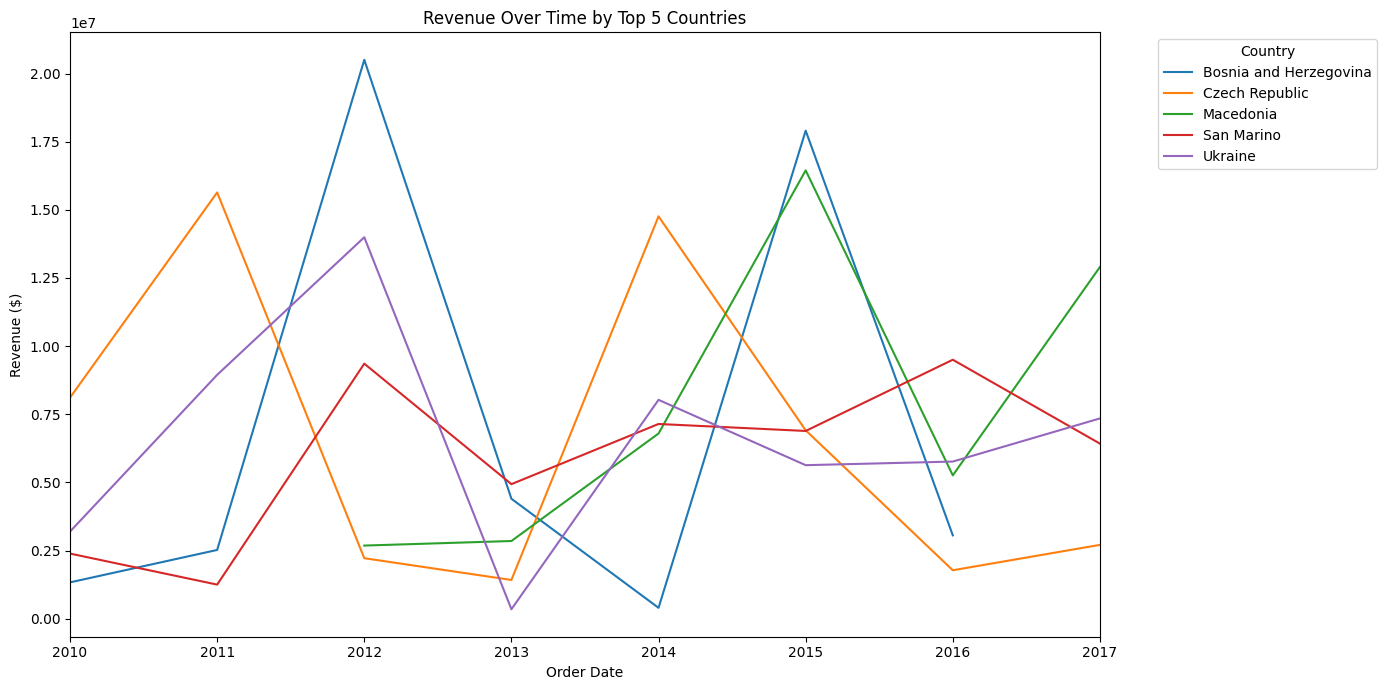

In [ ]:
top_countries = combain_data.groupby('name')['revenue'].sum().nlargest(5).index

yearly_by_country = combain_data[combain_data["name"].isin(top_countries)].groupby(
    [pd.Grouper(key='order_date', freq='YE'), 'name']
)['revenue'].sum().unstack()

yearly_by_country.plot(figsize=(14, 7))
plt.title('Revenue Over Time by Top 5 Countries')
plt.xlabel('Order Date')
plt.ylabel('Revenue ($)')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Revenue in the top 5 countries shows high year-to-year volatility rather than a consistent trend, suggesting that revenue in these markets is driven by a small number of large orders rather than steady, recurring sales volume.

In [ ]:
combain_data['month'] = combain_data['order_date'].dt.month_name()

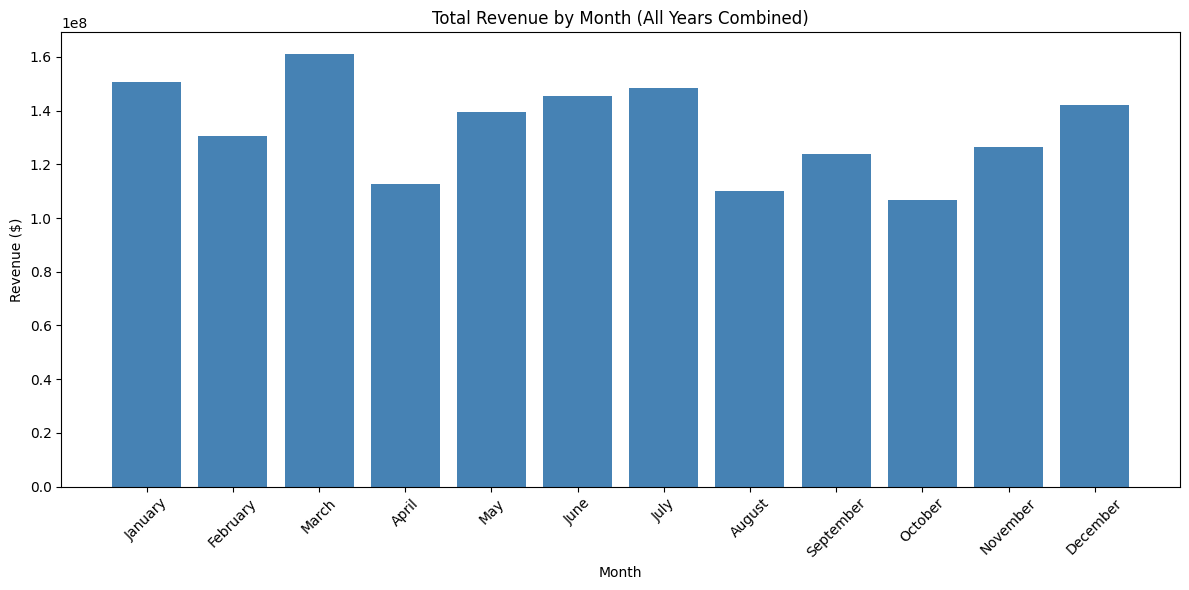

In [ ]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_totals = combain_data.groupby('month')['revenue'].sum().reindex(month_order)

plt.figure(figsize=(12, 6))
plt.bar(monthly_totals.index, monthly_totals.values, color='steelblue')
plt.title('Total Revenue by Month (All Years Combined)')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
monthly_totals.sort_values(ascending=False)

,revenue
month,
March,1.611303e+08
January,1.506701e+08
July,1.484595e+08
June,1.456073e+08
December,1.422889e+08
May,1.396645e+08
February,1.307131e+08
November,1.264608e+08
September,1.240175e+08


##  Sales by Day of Week

In [ ]:
combain_data['day_of_week'] = combain_data['order_date'].dt.day_name()

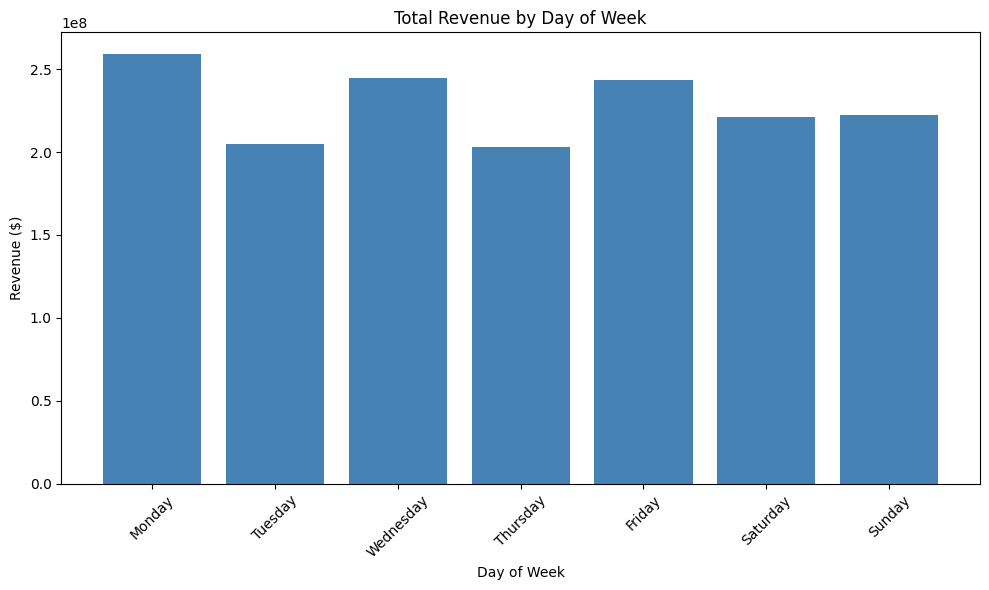

In [ ]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekly_sales = combain_data.groupby('day_of_week')['revenue'].sum().reindex(day_order)

plt.figure(figsize=(10, 6))
plt.bar(weekly_sales.index, weekly_sales.values, color='steelblue')
plt.title('Total Revenue by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

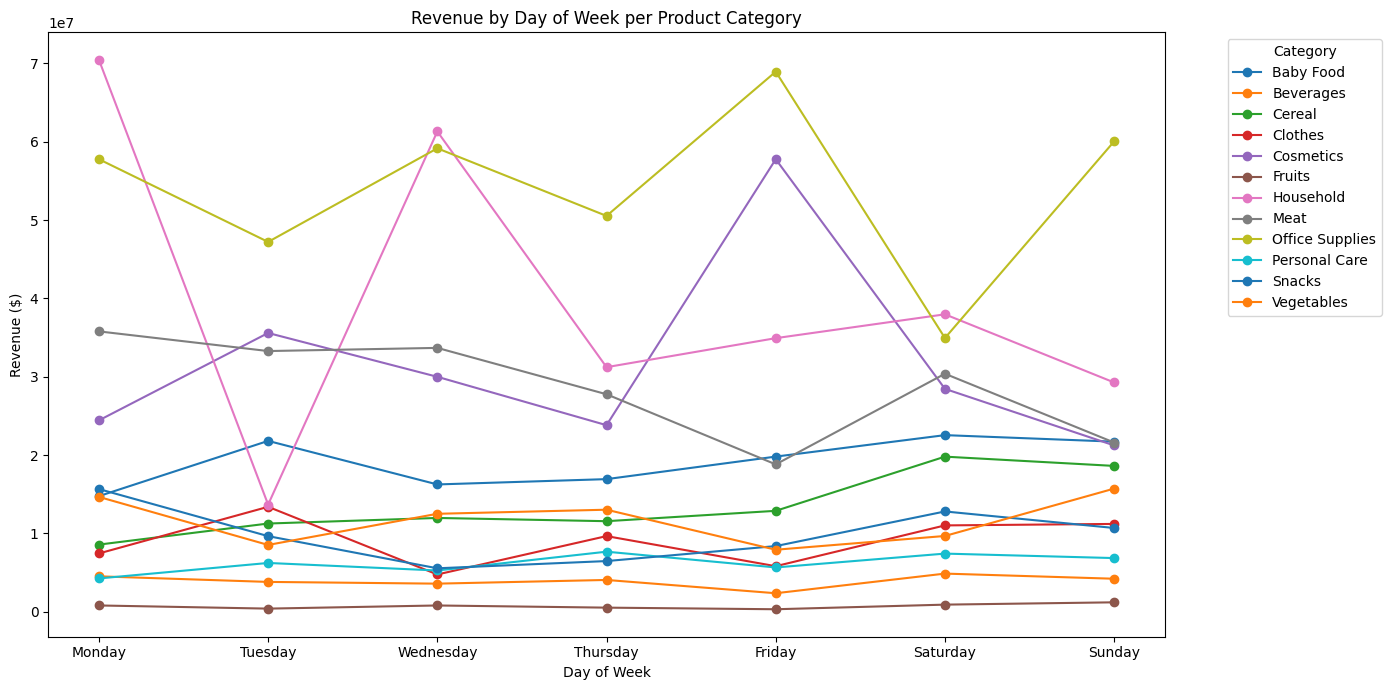

In [ ]:
weekly_by_category = combain_data.groupby(
    ['day_of_week', 'item_type']
)['revenue'].sum().unstack().reindex(day_order)

weekly_by_category.plot(figsize=(14, 7), marker='o')
plt.title('Revenue by Day of Week per Product Category')
plt.xlabel('Day of Week')
plt.ylabel('Revenue ($)')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
combain_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1246 entries, 0 to 1245
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          1246 non-null   int64         
 1   order_date        1246 non-null   datetime64[ns]
 2   ship_date         1246 non-null   datetime64[ns]
 3   product_id        1246 non-null   int64         
 4   sales_channel     1246 non-null   object        
 5   units_sold        1246 non-null   float64       
 6   unit_price        1246 non-null   float64       
 7   unit_cost         1246 non-null   float64       
 8   item_type         1246 non-null   object        
 9   name              1246 non-null   object        
 10  alpha-3           1246 non-null   object        
 11  region            1246 non-null   object        
 12  sub-region        1246 non-null   object        
 13  profit            1246 non-null   float64       
 14  revenue           1246 n

# Final Report

## Introduction
This report contains sales data for a company operating in the international market, both online and offline channels. The aim of the report is a basic analysis, including finding the most popular selling channel, product categories, countries, and regions, as well as showing sales trends and order fulfillment time.

## Data Description
The data contains three dataframes: "events", "products", and "countries". For more details, go to the [Conclusions](#conclusions) section.
They were joined together into the final "combain_data" dataframe.

## Cleaning Data
The data required cleaning before analysis.
Part of the data was missing, around 6% at its peak in the events dataframe. Since there was no key dependency in the missing data, I decided to delete those rows.
The date format in "Order Date" and "Ship Date" required conversion to datetime format.
Anomalies were found, such as Namibia's alpha-2 code ("NA") being incorrectly interpreted as NaN, which required a solution.

## Preparation for Analysis
All three dataframes (events, products, and countries) were joined together into the "combined_data" DataFrame. Moreover, columns such as profit, revenue, cost, delivery_time, and day_of_week were added to enable further analysis.

<a name="KPI"></a>
## KPI's
Total Orders: 1246
Total Revenue: \$1,598,983,761.26
Total Cost: \$1,125,274,726.20
Total Profit: \$473,709,035.06
Total Countries: 45

These numbers show the scale of the company's operations.

## Sales Analysis by Category / Location / Channel
The report contains charts covering all three dimensions.

### Categories
The differences in units sold between categories are not overwhelming; the most popular are Office Supplies, Clothes, and Beverages. However, the difference in revenue is clearly noticeable, with Office Supplies dominating. The difference in profit is more evenly distributed, with Cosmetics being the most profitable category.

### Location
The company operates on two continents: Europe and Asia, with Europe showing overwhelming dominance.

### Channel
The company sells through two channels, online and offline, with a practically equal 50/50 split.

## Analysis by Delivery Time
Charts and correlation analysis show no correlation between delivery time and order profit. The correlation score is r = 0.061, where r = 1.0 indicates a perfect positive correlation, r = 0.0 indicates no correlation, and r = -1.0 indicates a perfect negative correlation — showing that delivery speed has virtually no linear relationship with order profitability.

## Sales Trends Over Time
The overall structure of sales over time, broken down by category, region, and country, is fairly chaotic. Practically the only clear signal is a decline in sales in 2013, a slight increase with a peak in 2014/2015, and a slow decline until the end of the dataset.

### Regions
Europe is the company's main region, showing most of the fluctuation in sales, while sales in Asia remain at a similar, lower level for most of the period.

### Countries
There is no clear overall trend — some countries show unexpected spikes or disappear entirely from certain periods, such as Bosnia and Herzegovina in 2016. This is likely caused by isolated large orders.

## Sales Trends by Weekday and Month

### By Weekday
The analysis shows a slight trend in sales by weekday, with most sales occurring on Monday, Wednesday, and Friday, though the differences are not significant. The categories most susceptible to this trend are Office Supplies, Household, and Cosmetics.

### By Month
Most sales occur in March. There is also sales growth from May to July, and again from October to December, while October is the month with the lowest sales.

## Summary
The company sells in 45 countries across two continents (Europe and Asia). The data suggests a reliance on individual large orders, reflected in the substantial totals for amount, cost, and revenue, as shown in the [KPI](#KPI) section alongside the overall scale of the company's operations.Since delivery time shows no meaningful impact on profitability, the company may prioritize other factors — such as product mix or market expansion — over further investment in shipping speed optimization.